# Исследование заведений общественного питания рынка Москвы за лето 2022

## Цель и задачи

**Цель:** Провести исследовательский анализ данных общественного питания на рынке Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить категории, районы, сетевые/несетевые заведения, посадочные места и рейтинги;
    - изучить, с чем сильнее всего связан рейтинг заведения;
    - найти топ-15 сетей и изучить средний чек в зависимости от района.
4. Сформулировать итоговый вывод и рекомендации для заказчика.

## Данные

Данные собраны на основе сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года и разбиты на два файла.

### Описание датасета `rest_info`
Информация о заведениях общественного питания:
- `id` — идентификатор заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, например «Центральный административный округ»;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — является ли заведение сетевым (0 — нет, 1 — да; для маленьких сетей возможны ошибки);
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`
Информация о среднем чеке в заведениях:
- `id` — идентификатор заведения;
- `price` — категория цен, например «средние», «ниже среднего», «выше среднего»;
- `avg_bill` — средняя стоимость заказа в виде диапазона, например «Средний счет: 1000–1500 ₽» или «Цена одной чашки капучино: 130–220 ₽»;
- `middle_avg_bill` — оценка среднего чека; заполняется только для значений `avg_bill`, начинающихся с «Средний счет». Для диапазона — медиана двух чисел, для одного числа — само число, иначе пусто;
- `middle_coffee_cup` — оценка одной чашки капучино; заполняется только для значений `avg_bill`, начинающихся с «Цена одной чашки капучино». Логика та же, что и выше.

## Структура проекта

1. [Загрузка данных и знакомство с ними](#step1)
2. [Предобработка данных](#step2)
    - [2.1. Проверяем наличие пропусков в данных](#step2-1)
    - [2.2. Явные и неявные дубликаты в данных](#step2-2)
    - [2.3. Добавление нового столбца is_24_7](#step2-3)
    - [2.4. Промежуточный вывод по предобработке](#step2-4)
3. [Исследовательский анализ данных](#step3)
    - [3.1. Категории заведений](#step3-1)
    - [3.2. Административные районы](#step3-2)
    - [3.3. Сетевые и несетевые заведения](#step3-3)
    - [3.4. Количество посадочных мест](#step3-4)
    - [3.5. Рейтинг заведений](#step3-5)
    - [3.6. Корреляция рейтинга с другими признаками](#step3-6)
    - [3.7. Топ-15 популярных сетей](#step3-7)
    - [3.8. Средний чек в зависимости от района](#step3-8)
    - [Обобщение результатов исследования](#step3-sum)
4. [Итоговый вывод и рекомендации](#step4)

---

<a id="step1"></a>
## 1. Загрузка данных и знакомство с ними

Начнем с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных `rest_df` и `price_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

In [2]:
# Загружаем данные в два датафрейма
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 591.2 KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях.

При знакомстве с данными видно следующее:
1. Обнаружили новый столбец `id`, который не был указан в описании. Он содержит хэши, по которым потом будем связывать датасеты.
2. Пропуски есть в двух столбцах: в столбце `hours` заполнено 7870 из 8406 строк, то есть отсутствует 536 (6%) значений; в `seats` заполнено 4795, отсутствует 3611 (43%) значений.
3. Типы данных в целом соответствуют содержимому: числовые `rating`, `seats` (`float64`) и `chain` (`int64`), остальные — текстовые (`str`; это аналог `object` (использую свежую версию pandas не как в тренажере).
4. На предобработке стоит обратить внимание на два момента: значения в `hours` записаны по-разному (единый формат придется приводить), а в `seats` пропущено около 43% данных — это слишком много, чтобы просто удалить строки.

Теперь ознакомимся с данными датасета: `rest_price.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 158.6 KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке.

При знакомстве с данными видно следующее:

1. Обнаружили новый столбец `id`, который не был указан в описании. Он содержит такие же хэши, по которым потом будем связывать датасеты.
2. Пропуски есть в четырех столбцах: в столбце `price` заполнено 3315 из 4058 строк, то есть отсутствует 743 (18%) значений; в `avg_bill` заполнено 3816, отсутствует 242 (6%) значений; в `middle_avg_bill` заполнено 3149, отсутствует 909 (22%) значений; в `middle_coffee_cup` заполнено 535, отсутствует 3523 (87%) значений.
3. Типы данных в целом соответствуют содержимому: `price` и `avg_bill` – текстовый (`str`), правильно, остальные — числовые (`float64`) также правильно расставлены.
4. На предобработке стоит обратить внимание на пропуски в `middle_avg_bill` и `middle_coffee_cup` — они появляются из-за устройства самих колонок. Какие-то заведения отчитываются средним счетом, какие-то — ценой капучино, поэтому две колонки взаимоисключающие: где заполнена одна, там пуста другая. При этом вместе они покрывают не весь `avg_bill` — для части заведений цена записана в третьем формате (например, цена бокала пива), и тогда обе числовые колонки пустые.

Мы познакомились с обоими датасетами. Данные требуют предобработки: пропуски есть и местами значительные. При этом пропуски бывают двух типов — где-то это отсутствие данных (`hours`, `seats`), а где-то структурная особенность колонок (`middle_avg_bill` и `middle_coffee_cup`), которую чинить не нужно.

Теперь объединим датасеты в один датафрейм, с которым продолжим работу.

---

In [7]:
# Объединяем датасеты в один датафрейм df
df = rest_df.merge(price_df, on='id', how='left')

In [8]:
# Выводим получившуюся информацию о датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


**Вывод:**
1. Объединили датасеты по столбцу `id`. Взяли `rest_df` левой таблицей и `how='left'`, чтобы сохранить все заведения независимо от наличия у них цены — в результате все 8406 заведений на месте.
2. Во всех столбцах, пришедших из `price_df` (`price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`), ожидаемо появились пропуски у заведений, для которых данных о цене не было.

Переходим к предобработке данных.

---

<a id="step2"></a>
## 2. Предобработка данных

Названия столбцов уже в удобном формате (snake_case), менять их не требуется. По типам данных тоже приняли два решения:

- `downcast` числовых столбцов делать не будем — при 8406 строках (memory usage: 853.9 KB, меньше мегабайта) выигрыш по памяти незначителен.
- `seats` оставляем `float64`, а не переводим в `Int64`: место по природе целое, но `float` появился из-за пропусков (обычный `int` не хранит NaN), и на подсчеты это не влияет — точка в `4.0` лишь отображение, дробных значений там нет.

В остальном типы соответствуют содержимому, преобразований не требуется.

<a id="step2-1"></a>
### 2.1. Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбцах `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

In [9]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [10]:
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` обнаружили пропуски в столбцах: `hours` (536 — 6%), `seats` (3611 — 43%) — это пропуски из данных о заведениях. Также пропуски появились после соединения с данными о средних чеках: `price` (5091 — 61%), `avg_bill` (4590 — 55%), `middle_avg_bill` (5257 — 63%), `middle_coffee_cup` (7871 — 94%). В ценовых столбцах пропусков особенно много, и выросли они из-за соединения: цены нашлись только для 4058 заведений, а у оставшихся ~4348 ценовые поля пустые.

У пропусков в ценовых столбцах две разные причины, и их полезно не путать. Часть — заведение вообще не попало в `price_df` (нет строки о цене). Часть — строка есть, но конкретное поле пустое (например, `middle_coffee_cup` пуст, потому что заведение отчитывается средним счетом).

Чтобы понять природу пропусков, посмотрим, связаны ли они с другими данными. Для этого добавим два признака-индикатора: `is_seats` (указано ли количество мест) и `is_hours` (указаны ли часы работы). По `seats` пропусков много (43%), и причина неочевидна — возможно, она связана с категорией заведения (например, заведения навынос), это и проверим. По `hours` пропусков мало (6%), но заодно тоже посмотрим, нет ли закономерности.

Ценовые столбцы профилировать не будем: причина пропусков в них уже понятна — заведение либо не попало в `price_df`, либо цена записана в формате, который не парсится в числовые колонки.

In [11]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    if x:
        return 0
    return 1

Функция применяется к столбцу, в котором следует проверить данные, после метода `isna()`. Если пропуск есть, возвращает `True`. В случае `True` срабатывает условие `if x` — функция возвращает 0, что означает, что в столбце нет данных. Если пропуска нет, метод `isna()` вернет `False`. Тогда условие `if x` не сработает, и код вернет 1. Применим эту функцию к столбцу `seats` и создадим новый столбец `is_seats`:

In [12]:
# Создаем столбец is_seats с помощью функции create_is_na
df['is_seats'] = df['seats'].isna().apply(create_is_na)

После того как столбец-признак `is_seats` был создан, можно посчитать средние значения или медиану по другим столбцам. Это поможет получить характеристики заведений с пропуском и без пропуска в столбце `seats`. Для этого проведем агрегацию данных:

- Для данных с дискретными признаками `rating` будем использовать медиану `median`. Берем медиану, как устойчивую к выбросам, в отличие от среднего, меру центра.
- Для категориальных данных `category` используем `value_counts`, то есть нужно смотреть на распределение значений.
- Для бинарных данных `chain` также используем среднее значение `mean` — оно будет соответствовать доли значений с признаком 1.

In [13]:
# Проводим агрегацию данных по полю is_seats

df.groupby('is_seats').agg({
    'rating': 'median',
    'chain': 'mean'
})

,rating,chain
is_seats,,
0,4.3,0.353919
1,4.3,0.401877


Что показало сравнение групп:
1. Медианный рейтинг в обеих группах одинаковый — 4.3. Значит, наличие пропуска в `seats` с рейтингом не связано. (При этом помним: рейтинг может быть 5.0 всего по паре отзывов, а числа оценок у нас нет — это ограничение данных.)
2. Доля сетевых заведений в группах почти не отличается: 0.35 без мест и 0.40 с местами. Разница незначительная, так что и с сетевостью пропуск мест заметно не связан.

Оба проверенных фактора пропуски в `seats` не объясняют. Осталось проверить главную гипотезу — связаны ли пропуски с категорией заведения.

---

Проверим категориальные данные

In [14]:
# Применим метод value_counts и посмотрим на распределение значений
df['category'].value_counts(normalize=True)

category
кафе               0.282893
ресторан           0.243041
кофейня            0.168094
бар,паб            0.091006
пиццерия           0.075303
быстрое питание    0.071734
столовая           0.037473
булочная           0.030454
Name: proportion, dtype: float64

In [15]:
# Посчитаем среди заведений без мест
df[df['is_seats'] == 0]['category'].value_counts(normalize=True)

category
кафе               0.321241
ресторан           0.214068
кофейня            0.183329
бар,паб            0.082249
быстрое питание    0.070341
пиццерия           0.057048
столовая           0.041817
булочная           0.029909
Name: proportion, dtype: float64

Первый `value_counts` показал структуру группы: среди заведений без мест лидируют кафе — но лишь потому, что кафе много в датасете вообще. Поэтому сравним иначе — посчитаем долю пропусков внутри каждой категории через среднее `is_seats` по группам.

In [16]:
# Посчитаем среднее по каждой категории для значений is_seats
df.groupby('category')['is_seats'].mean().sort_values()

category
кафе               0.512195
столовая           0.520635
кофейня            0.531493
булочная           0.578125
быстрое питание    0.578773
бар,паб            0.611765
ресторан           0.621635
пиццерия           0.674566
Name: is_seats, dtype: float64

По категориям видно следующее:
1. Чаще без указания мест оказались кафе (49%), столовые (48%) и кофейни (47%). Реже всего — пиццерии (33%), рестораны (38%) и `бар,паб` (39%).
2. Разница небольшая: во всех категориях места не указывают примерно с одинаковой частотой. Похоже, это про полноту заполнения данных, а не про свойство заведения.
3. Гипотеза про навынос не подтвердилась — беззальные форматы (кофейни, быстрое питание) по данным не выбиваются.

После профилирования по дискретным, категориальным и бинарным признакам: рейтинг с пропуском не связан, сетевость связана слабо, категория дает лишь небольшой уклон. Ни один проверенный фактор пропуски в `seats` убедительно не объясняет.

---

Проверим нет ли закономерностей по столбцу `hours`.

In [17]:
# Создаем столбец is_hours с помощью функции create_is_na
df['is_hours'] = df['hours'].isna().apply(create_is_na)

In [18]:
# Проводим агрегацию данных по полю is_hours

df.groupby('is_hours').agg({
    'rating': 'median',
    'chain': 'mean'
})

,rating,chain
is_hours,,
0,4.2,0.216418
1,4.3,0.392503


In [19]:
# Посчитаем среднее по каждой категории для значений is_seats
df.groupby('category')['is_hours'].mean().sort_values()

category
кафе               0.842304
быстрое питание    0.945274
ресторан           0.963779
столовая           0.971429
булочная           0.972656
бар,паб            0.976471
кофейня            0.989384
пиццерия           0.992101
Name: is_hours, dtype: float64

По столбцу `hours` картина такая:

1. Связь с сетевостью заметнее, чем у `seats`: среди заведений с указанными часами доля сетевых выше (39% против 22%). Похоже, сетевые точки заполняют карточки полнее, а у одиночных несетевых чаще некому это сделать.
2. Кафе опять выбивается вниз: около 16% без часов, тогда как у пиццерий почти все указаны (~1% без часов). У кафе стабильно хуже заполнены карточки — и по местам, и по часам это мягкий, но повторяющийся паттерн.
3. Пропусков всего 6%, на анализ это существенно не повлияет — оставляем как есть.
    
---
Столбцы `is_seats` и `is_hours` были нужны только для анализа пропусков и в дальнейшем не понадобятся, поэтому удалим их.

In [20]:
df = df.drop(columns=['is_seats', 'is_hours'])

In [21]:
# Убедимся, что столбцов стало 13
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


**Вывод:**

Пропуски решено оставить во всех столбцах. Профилирование `seats` и `hours` не выявило системной причины пропусков (нашлись лишь слабые связи – например, несетевые заведения и кафе чуть реже заполняют карточку), а пропуски в ценовых столбцах структурны: заведение либо не попало в `price_df`, либо цена записана в формате, который не парсится в числовые колонки. Заполнять такие пропуски нечем и незачем, удалять строки нельзя из-за большого объема – поэтому оставляем как есть.

---

<a id="step2-2"></a>
### 2.2. Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнем с полных дубликатов:

In [22]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

np.int64(0)

В датафрейме нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` заведений должны быть уникальными, то есть каждая строка в данных — уникальное заведение:

In [23]:
# Проверяем неявные дубликаты в датафрейме df
df.duplicated(subset='id').sum()

np.int64(0)

Тут тоже все хорошо — каждая строка соответствует уникальному заведению. Теперь проверим корректность написания категориальных значений.

In [24]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['category', 'district']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
<StringArray>
[        'бар,паб',        'булочная', 'быстрое питание',            'кафе',
         'кофейня',        'пиццерия',        'ресторан',        'столовая']
Length: 8, dtype: str

Уникальные значения в столбце district:
<StringArray>
[       'Восточный административный округ',
         'Западный административный округ',
         'Северный административный округ',
 'Северо-Восточный административный округ',
  'Северо-Западный административный округ',
      'Центральный административный округ',
    'Юго-Восточный административный округ',
     'Юго-Западный административный округ',
            'Южный административный округ']
Length: 9, dtype: str



В обозначении категории и административного района также нет ошибок.

Проверим `name` и `address` на наличие неявных дубликатов. Создадим `name_clean`, чтобы сохранить результаты, если проблем не будет после нормализации данных – приведения к нижнему регистру + обрезка пробелов.

In [25]:
# Нормализуем данные столбца name в новом столбце name_clean
df['name_clean'] = df['name'].str.lower().str.strip()

In [26]:
# Проверим на неявные дубликаты
df.duplicated(subset=['name_clean', 'address']).sum()

np.int64(3)

In [27]:
# Смотрим на найденные неявные дубли
df[df.duplicated(subset=['name_clean', 'address'], keep=False)].sort_values('name_clean')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_clean
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN,more poke
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN,more poke
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни и Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN,раковарня клешни и хвосты
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN,раковарня клешни и хвосты
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN,хлеб да выпечка
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN,хлеб да выпечка


Обнаружилось 3 дубликата. На первый взгляд они одинаковые, но отличаются не только регистром названия: у «More Poke» различается `chain` (1 и 0), у «Раковарня Клешни и Хвосты» — тоже `chain`, и у «Хлеб да Выпечка» — аналогично. Вдобавок у «Раковарни» и «Хлеб да Выпечка» отличаются категории заведения. Похоже, это одно и то же заведение, попавшее в данные дважды из разных источников с немного разными атрибутами.

Решение: удалить дубли, оставив по одной записи из каждой пары. Какая именно строка останется — по сути неважно, так как дублей всего 3, и их влияние на категории, районы и рейтинги пренебрежимо мало.

In [28]:
df = df.drop_duplicates(subset=['name_clean', 'address']).reset_index(drop=True)

In [29]:
# Проверка, что сработало
df.duplicated(subset=['name_clean', 'address']).sum()

np.int64(0)

In [30]:
# name_clean отслужил — удаляем служебный столбец
df = df.drop(columns='name_clean')

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8403 entries, 0 to 8402
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8403 non-null   str    
 1   name               8403 non-null   str    
 2   category           8403 non-null   str    
 3   address            8403 non-null   str    
 4   district           8403 non-null   str    
 5   hours              7868 non-null   str    
 6   rating             8403 non-null   float64
 7   chain              8403 non-null   int64  
 8   seats              4792 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.6 KB


**Вывод:** 

- Явных (полных) дубликатов в данных нет, значения `id` уникальны — каждая строка соответствует отдельному заведению. После нормализации названия (нижний регистр + обрезка пробелов) обнаружились 3 неявных дубликата по паре «название + адрес»: одно и то же заведение попало в данные дважды из разных источников с немного разными атрибутами. Дубли удалили, оставив по одной записи. После очистки осталось 8403 заведения.

<a id="step2-3"></a>
### 2.3. Добавление нового столбца is_24_7

Для дальнейшего анализа круглосуточных заведений выделим бинарный столбец `is_24_7`: `True`, если заведение работает ежедневно и круглосуточно, и `False` в остальных случаях. Определять режим будем по столбцу `hours`. Сначала посмотрим, в каких формулировках в данных встречается круглосуточный режим, — чтобы не пропустить варианты написания.

In [32]:
# Находим все уникальные формулировки со словом «круглосуточно»
df[df['hours'].str.contains('круглосуточно', na=False)]['hours'].unique()

<StringArray>
[                                                                   'ежедневно, круглосуточно',
 'пн 00:01–12:00, перерыв 12:00–13:30; вт-чт 13:30–12:00; пт 13:30–00:00; сб,вс круглосуточно',
                                                                         'вт-вс круглосуточно',
                                                                            'сб круглосуточно',
                                                                         'пт-вс круглосуточно',
                                                             'пн,ср,чт,пт,сб,вс круглосуточно',
                                         'пн 10:00–00:00; вт-сб круглосуточно; вс 00:00–23:00',
                         'пн-чт 07:30–23:00; пт 07:30–00:00; сб круглосуточно; вс 00:00–23:00',
         'пн круглосуточно; вт-чт 12:00–00:00; пт 12:00–02:00; сб 11:00–02:00; вс 14:00–00:00',
                                      'пн-чт 08:00–23:00; пт,сб круглосуточно; вс 08:00–23:00',
                      'пн-

In [33]:
# Создаем булев столбец is_24_7: True, если заведение работает ежедневно и круглосуточно
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

In [34]:
# Проверяем распределение значений в новом столбце
df['is_24_7'].value_counts()

is_24_7
False    7673
True      730
Name: count, dtype: int64

**Вывод:**
- Создали булев столбец `is_24_7`: `True`, если `hours` точно совпадает со строкой «ежедневно, круглосуточно», иначе `False`.
- Выбрали точное совпадение, а не проверку на слово «круглосуточно»: в данных есть формулировки, где заведение работает круглосуточно лишь по отдельным дням, — это не 24/7 по смыслу ТЗ.
- Получилось 730 круглосуточных заведений (около 9%).

<a id="step2-4"></a>
### 2.4. Промежуточный вывод по предобработке

На этапе предобработки данные были подготовлены к анализу:

- **Названия столбцов** уже были в удобном формате (snake_case), приводить их не потребовалось.
- **Типы данных** в целом соответствуют содержимому, преобразований не делали. `downcast` не применяли — при таком объеме данных выигрыш по памяти незначителен. `seats` оставили `float64`: место по природе целое, но `float` возник из-за пропусков (обычный `int` не хранит NaN), и на подсчеты это не влияет.
- **Пропуски** изучили и решили оставить во всех столбцах. Профилирование `seats` и `hours` не выявило системной причины пропусков (нашлись лишь слабые связи с сетевостью и категорией). Пропуски в ценовых столбцах структурны: заведение либо не попало в данные о ценах, либо цена записана в формате, который не парсится в числовые колонки. Заполнять такие пропуски нечем, а удалять строки нельзя из-за большого объема.
- **Дубликаты**: явных дублей нет, значения `id` уникальны. После нормализации названия обнаружили и удалили 3 неявных дубликата (одно заведение, попавшее в данные дважды из разных источников). Отфильтровано 3 строки из 8406 — около 0,04%.
- **Новый столбец** `is_24_7` выделили из `hours`: `True` для заведений с режимом «ежедневно, круглосуточно» (730 заведений, ~9%), иначе `False`.

После предобработки в данных осталось **8403 заведения** и 13 столбцов. Данные готовы к исследовательскому анализу.

<a id="step3"></a>
## 3. Исследовательский анализ данных
<a id="step3-1"></a>
### 3.1. Категории заведений

Изучим, какие категории заведений представлены в данных и сколько объектов приходится на каждую. Посчитаем количество заведений по категориям и построим столбчатую диаграмму — она наглядно покажет, какие категории встречаются чаще всего.

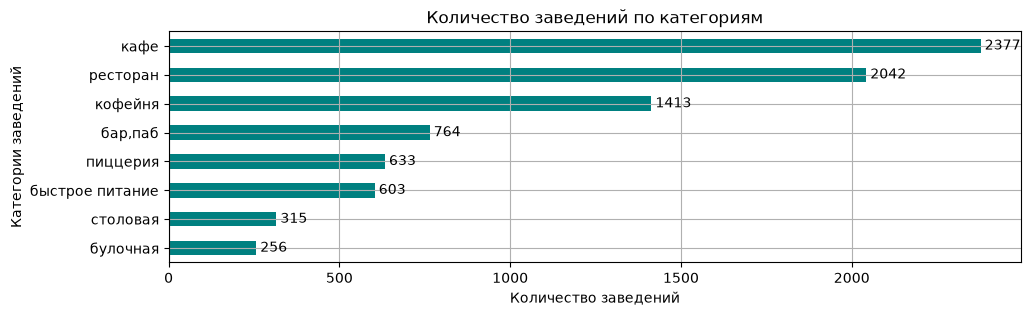

In [35]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
ax = df['category'].value_counts().sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Количество заведений по категориям'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Категории заведений')
plt.xlabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**
1. По категориям видны явные лидеры: кафе (2377) и ресторан (2042) — две категории, у которых больше 2000 заведений. Следом идут кофейни (1413).
2. После этой тройки — резкое падение: бар,паб ~764, пиццерия ~633, быстрое питание ~603.
3. Разница между лидером и аутсайдером почти десятикратная (2377 против 256), самые редкие форматы — столовые (315) и булочные (256).
4. На рынке доминируют кафе, рестораны и кофейни; узкие форматы — столовые и булочные — представлены слабо.

<a id="step3-2"></a>
### 3.2. Административные районы

Изучим, как заведения распределены по административным округам Москвы. Отдельно рассмотрим распределение категорий заведений в Центральном административном округе. Результат сопроводим визуализациями.

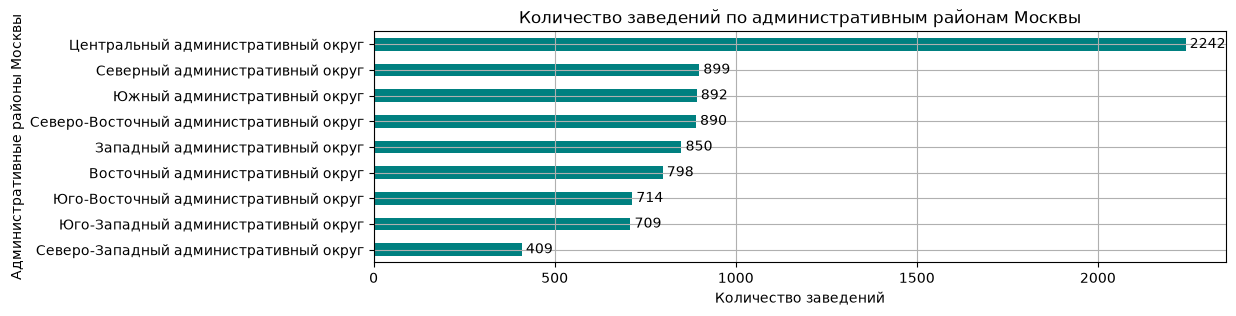

In [36]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
ax = df['district'].value_counts().sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Количество заведений по административным районам Москвы'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Административные районы Москвы')
plt.xlabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**
1. Выявлено доминирование ЦАО над другими округами. Количество заведений в ЦАО 2242, что почти в 2,5 раза больше, чем в ближайшем.
2. Остальные округа сопоставимы между собой (примерно 700–900 заведений), кроме аутсайдера — СЗАО с 409 заведениями, что примерно в 1,7 раза меньше, чем у ЮЗАО (709).
3. Если ориентироваться по количеству, конкуренция явно выше в ЦАО: открываться там стоит, если есть сильный продукт и готовность бороться за клиента. Если же нужна низкая конкуренция, разумнее смотреть на округа из середины списка. Аутсайдера (СЗАО) лучше не брать вслепую — неизвестно, низкая там конкуренция из-за свободного рынка или из-за низкого спроса.

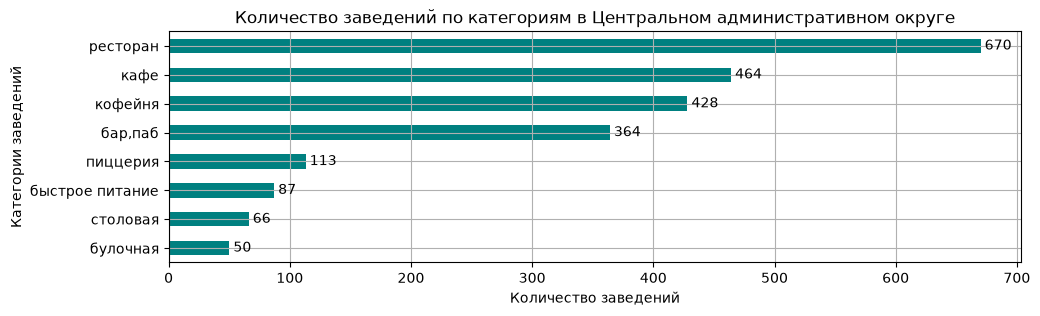

In [37]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
ax = df[df['district'] == 'Центральный административный округ']['category'].value_counts().sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Количество заведений по категориям в Центральном административном округе'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Категории заведений')
plt.xlabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**
1. В ЦАО на первое место выходят рестораны, тогда как по городу лидируют кафе. В центре популярнее ресторанный формат — это логично для деловой и туристической части города. Также заметно, что кофейни почти догоняют кафе (428 против 464), хотя по городу отставали сильнее, а бары и пабы (364) подтянулись к тройке лидеров — по городу они были заметно ниже.
2. Аутсайдер — булочная, как и по городу. Важно: это говорит только о малом количестве таких заведений, а не о низком спросе — данные о востребованности у нас нет.
3. Если ориентироваться на количество, самая высокая конкуренция — в сегменте ресторанов, туда стоит заходить с сильным продуктом, ведь у клиента и так большой выбор. Бары и пабы, подтянувшиеся к лидерам, могут указывать на востребованность формата в центре — но уверенно судить об этом можно было бы только по данным в динамике, которых у нас нет.

<a id="step3-3"></a>
### 3.3. Сетевые и несетевые заведения

Изучим соотношение сетевых и несетевых заведений в целом по городу. Отдельно посмотрим, какие категории чаще бывают сетевыми. Результат сопроводим визуализациями.

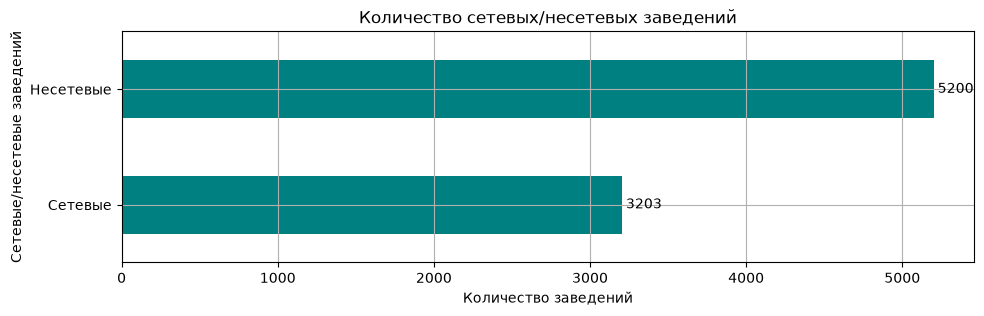

In [38]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh'), также переименуем 0 и 1 на соответсвующие названия для понимания
ax = df['chain'].value_counts().sort_values().rename({0: 'Несетевые', 1: 'Сетевые'}).plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Количество сетевых/несетевых заведений'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Сетевые/несетевые заведений')
plt.xlabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Несетевых заведений заметно больше их 5200 (62%), а сетевых 3203 (38%). То есть большинство заведений Москвы работают сами по себе, не под сетевым брендом.

Теперь узнаем долю сетевых по категориям.

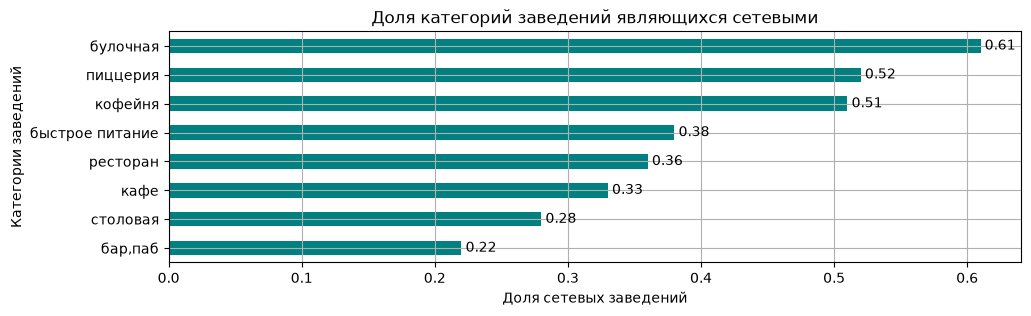

In [39]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh'), по категориям заведений
ax = df.groupby('category')['chain'].mean().round(2).sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Доля категорий заведений являющихся сетевыми'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Категории заведений')
plt.xlabel('Доля сетевых заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**

1. Несетевых заведений по городу больше, чем сетевых (62% против 38%). Это объясняется тем, что рынок наполнен мелкими одиночными точками — шаурмичными, небольшими кафе и ресторанами.
2. Самая сетевая категория — булочная (61% булочных сетевые), далее пиццерия (52%) и кофейня (51%). Аутсайдер — бар,паб: сетевых всего 22%.
3. Сетевые чаще встречаются в стандартизируемых форматах (булочные, пиццерии, кофейни) — их меню и процесс легко копировать под единым брендом. Там, где важна уникальность концепции (бары) или привязка к месту (столовые), заведения чаще одиночные. Это не значит, что кофейням или булочным не нужна индивидуальность, — просто их формат проще тиражировать.
4. Быстрое питание оказалось не таким сетевым, как можно было ожидать (KFC, McDonald's и т.п. в 22 году вроде не сразу ушли) — всего 38%. Видимо, в этой категории много одиночных точек вроде шаурмичных.
5. Высокая доля сетевых у булочных не означает, что они весомая часть сетевого рынка: булочных всего 256 — это самая маленькая категория, поэтому к этому проценту стоит относиться осторожнее, чем, например, к кофейням (их 1413).

<a id="step3-4"></a>
### 3.4. Количество посадочных мест

Изучим количество посадочных мест в заведениях: встречаются ли аномальные значения или выбросы, и если да — с чем они могут быть связаны. Для каждой категории приведем типичное количество мест. Результат сопроводим визуализациями.

In [40]:
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Основная масса заведений имеет от 40 до 140 мест (медиана — 75). При этом среднее (108) заметно выше медианы, а максимум достигает 1288 — это признак правого хвоста: редкие крупные заведения тянут среднее вверх. Чтобы разглядеть выбросы и форму распределения, построим boxplot и гистограмму.

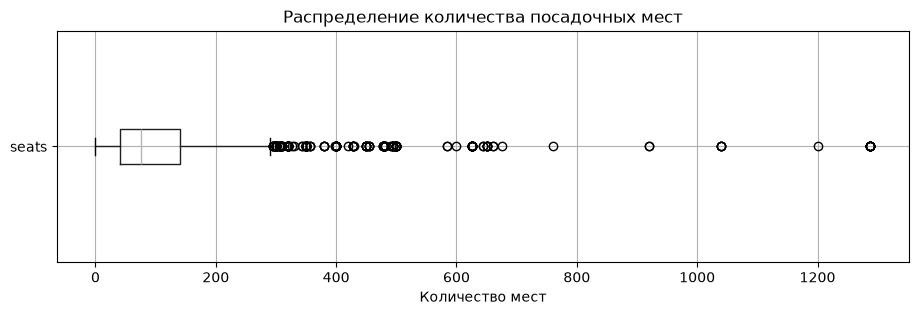

In [41]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим ящик с усами
df.boxplot(column='seats', vert=False)   # vert=False — горизонтальный, удобнее читать

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.show()

На boxplot хорошо видно: основная масса значений прижата влево, примерно от 40 до 140 мест — это обычные заведения. Дальше вправо тянется длинный шлейф точек-выбросов вплоть до 1288 мест — редкие крупные заведения.

Типичное количество мест правильнее оценивать по медиане (75), а не по среднему (108): среднее завышено из-за выбросов, которые тянут его вверх, а медиана к ним устойчива.

Выбросы решено не удалять. Во-первых, значения вроде 1288 мест выглядят реальными (крупные столовые, банкетные залы), а не ошибками ввода — удалять настоящие заведения из анализа рынка нет оснований. Во-вторых, для типичного значения мы используем медиану, на которую выбросы и так не влияют, — то есть удаление ничего бы не изменило.

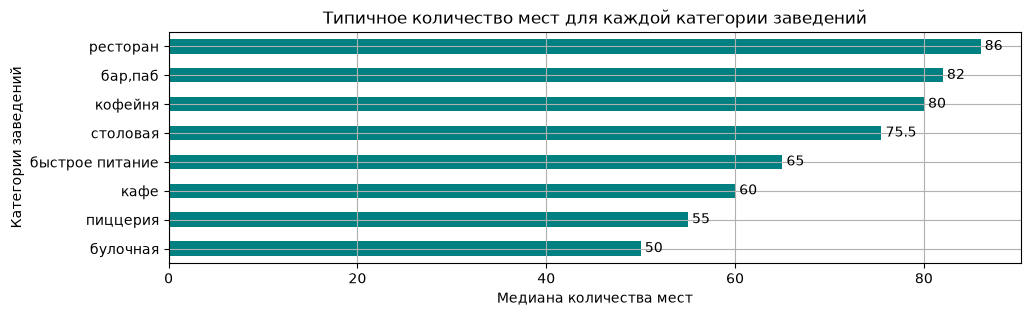

In [42]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh'), высчитывая медиану для категорий
ax = df.groupby('category')['seats'].median().sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Типичное количество мест для каждой категории заведений'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Настраиваем оформление графика
plt.ylabel('Категории заведений')
plt.xlabel('Медиана количества мест')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**

1. Основная масса заведений имеет от 40 до 140 мест, типичное значение (медиана) — 75 мест. В данных есть выбросы (максимум 1288), распределение с правым хвостом: немного крупных заведений с большим числом мест вытягивают распределение вправо. Среднее (108) завышено из-за этих выбросов, поэтому за типичное значение берем медиану — она к выбросам устойчива.
2. Выбросы решено не удалять: такие высокие значения могут быть реальными (банкетные залы, столовые при предприятиях). Из любопытного — заведение на 1288 мест оказалось кофейней, что похоже на ошибку категоризации или фудкорт. Медиане выбросы не мешают, поэтому удалять их нет смысла.
3. По категориям типично больше всего мест у ресторанов (86), баров/пабов (82) и кофеен (80), меньше всего — у булочных (50) и пиццерий (55). Интересно, что кофейни, которые ждешь как формат навынос, оказались посадочными: половина кофеен имеет 40–144 места. В целом типичные размеры заведений всех категорий сопоставимы (медианы в диапазоне 50–86), резкой разницы нет — большой разброс дают отдельные гиганты-выбросы. При выборе размера будущего заведения можно ориентироваться на эти типичные значения.

<a id="step3-5"></a>
### 3.5. Рейтинг заведений

Изучим рейтинг заведений: визуализируем распределение средних рейтингов по категориям и ответим, сильно ли различаются усредненные рейтинги для разных типов общепита.

In [43]:
df['rating'].describe()

count    8403.000000
mean        4.229894
std         0.470426
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Основная масса заведений имеет рейтинг от 4.1 до 4.4, медиана - 4.3, среднее - 4.23. Разница между средним и медианой всего 0.1, то есть перекоса нет. Рейтинг ограничен диапазоном от 1 до 5, поэтому одно заведение не способно утащить среднее так, как это делали крупные заведения в столбце `seats`, - значит, здесь можно опираться на среднее значение, а не на медиану. Стандартное отклонение всего 0.47: рейтинги плотно сгруппированы вокруг 4.2-4.3, разброс небольшой.

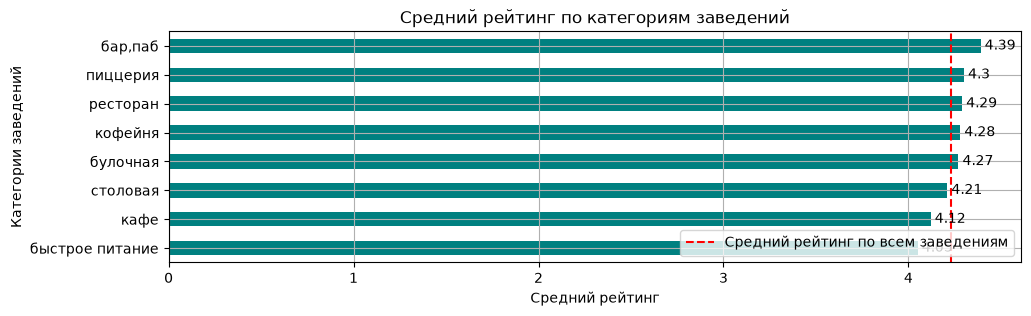

In [44]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh'), высчитывая среднее значение для категорий
ax = df.groupby('category')['rating'].mean().round(2).sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Средний рейтинг по категориям заведений'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Построим линию среднего значения, чтобы явно понять какие категории обычно хуже
line = plt.axvline(df['rating'].mean(), color='red', linestyle='--', label='Средний рейтинг по всем заведениям')
plt.legend(handles=[line], loc='lower right')  # в легенде оставляем только линию среднего

# Настраиваем оформление графика
plt.ylabel('Категории заведений')
plt.xlabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод:**

1. Самый высокий средний рейтинг у баров и пабов — 4.39, далее пиццерии (4.3) и рестораны (4.29). Все они выше общего среднего по городу (4.23).
2. Аутсайдер — быстрое питание (4.05), за ним кафе (4.12) и столовые (4.21). Все три категории ниже общего среднего.
3. При этом различия между категориями очень небольшие: разброс средних всего 0.34 балла (от 4.05 до 4.39), и он даже меньше общего стандартного отклонения рейтинга (0.47). То есть разница между категориями меньше, чем разброс внутри любой из них — говорить о существенном отличии усредненных рейтингов по типам общепита нельзя.
4. Почему бары наверху, а фастфуд внизу, по этим данным сказать нельзя. Можно только предполагать: например, в бар идут отдыхать и оценивают охотнее, чем столовую в обеденный перерыв. Проверить такие версии на имеющихся данных не получится.
5. Надежность оценок разная. Средний рейтинг кафе (2377 заведений) и ресторанов (2042) опирается на большое число объектов, а вот 4.27 у булочных посчитан всего по 256 — к нему стоит относиться осторожнее.
6. Отдельное ограничение: количества оценок в данных нет. У какого-то заведения может быть 3–4 отзыва, все на 5 звезд, и это будет выглядеть так же весомо, как рейтинг 4.4 по тысяче отзывов. Это нужно учитывать при интерпретации.

<a id="step3-6"></a>
### 3.6. Корреляция рейтинга с другими признаками

Изучим, с какими данными рейтинг заведения связан сильнее всего. Построим матрицу корреляции рейтинга с категорией заведения, административным округом, статусом сетевого, количеством посадочных мест, ценовой категорией и признаком круглосуточной работы.

Обычный коэффициент Пирсона здесь не подходит: `category`, `district` и `price` — категориальные (текстовые) данные, а Пирсон измеряет линейную связь только между числовыми переменными и такие столбцы просто не учтет. Поэтому используем `phi_k` — он работает с любыми типами данных: числовыми, категориальными и смешанными. Затем выберем самую сильную связь и рассмотрим ее отдельно.

In [45]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['rating', 'category', 'district', 'chain',
                         'seats', 'price', 'is_24_7']].phik_matrix(
                             interval_cols=['rating', 'seats'])

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.200701
category,0.189904
is_24_7,0.150210
chain,0.108060
seats,0.000000


Все связи оказались слабыми — максимум 0.22 у `price`. Это значит, что рейтинг заведения почти не объясняется ни его типом, ни расположением, ни ценовой категорией, ни сетевым статусом. Скорее всего, он определяется тем, чего в данных нет: качеством еды, сервисом, атмосферой.

У `seats` коэффициент ровно 0. `phi_k` не выдает отрицательных значений: если связь не сильнее случайной, он возвращает ноль. То есть количество мест с рейтингом не связано — большое заведение оценивают не лучше и не хуже маленького.

Первое место занял `price`, но с важной оговоркой: в этом столбце пропущено 61% значений, то есть коэффициент посчитан примерно по 39% заведений, тогда как `category` и `district` считались по всем 8403. Сравнивать силу связей напрямую поэтому нужно осторожно.

Теперь визуализируем матрицу.

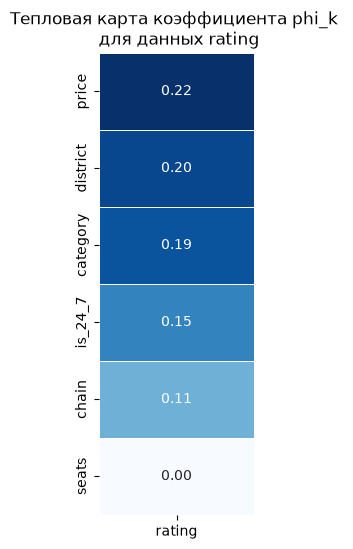

In [46]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками 
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='Blues', # Последовательная палитра: чем темнее, тем сильнее связь
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')

# Выводим график
plt.show()

Изучим, существует ли зависимость между рейтингами и ценами. Для этого построим столбчатые диаграммы с разделением по признаку `rating` среди разных ценовых категорий:

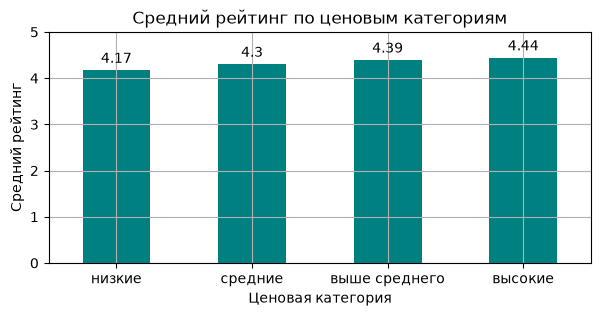

In [47]:
# Задаем осмысленный порядок ценовых категорий — от дешевых к дорогим
new_index = ['низкие', 'средние', 'выше среднего', 'высокие']

grouped = df.groupby('price')['rating'].mean().round(2).reindex(new_index)

ax = grouped.plot(kind='bar',
                  title='Средний рейтинг по ценовым категориям',
                  ylabel='Средний рейтинг',
                  xlabel='Ценовая категория',
                  rot=0,
                  color='teal',
                  figsize=(7, 3))

ax.bar_label(ax.containers[0], padding=3)
plt.ylim(0, 5)   # рейтинг ограничен диапазоном 1-5, показываем всю шкалу
plt.grid()
plt.show()

Прежде чем делать выводы о связи рейтинга с ценой, посмотрим на размеры ценовых категорий — от количества заведений в группе зависит надежность среднего значения.

In [48]:
# Проверяем размеры ценовых категорий, чтобы оценить надежность средних рейтингов
df['price'].value_counts()

price
средние          2117
выше среднего     564
высокие           478
низкие            156
Name: count, dtype: int64

**Вывод:**

1. На графике видна тенденция: чем выше ценовая категория, тем выше средний рейтинг — низкие (4.17), средние (4.3), выше среднего (4.39), высокие (4.44). Рост монотонный, без провалов. Направление связи `phi_k` показать не мог, его удалось увидеть только этой проверкой.
2. При этом разница невелика: разброс всего 0.27 балла на шкале от 1 до 5. Это согласуется с самим коэффициентом `phi_k` (0.22) — связь есть, но слабая.
3. Нужно учитывать два ограничения. Во-первых, `price` заполнен только у 39% заведений. Во-вторых, группы очень неравные: в категории «низкие» всего 156 заведений против 2117 у «средних», а на маленькой группе средний рейтинг неустойчив — несколько случайных значений заметно его сдвинут.
4. Так что вывод «дорогие заведения оценивают выше» по этим данным сделать можно, но осторожно — прежде всего из-за малой группы дешевых заведений. И причину связи данные не раскрывают: поднять цены, чтобы вырос рейтинг, не получится.

<a id="step3-7"></a>
### 3.7. Топ-15 популярных сетей

Найдем 15 самых популярных сетей Москвы. Под популярностью здесь понимается количество заведений сети в регионе. Для каждой сети посчитаем средний рейтинг и посмотрим, к каким категориям они относятся. Результат сопроводим визуализациями.

In [49]:
# Проверяем, дробит ли регистр названия сетей
print('Уникальных названий как есть:', df['name'].nunique())
print('Уникальных названий в нижнем регистре:', df['name'].str.lower().nunique())

Уникальных названий как есть: 5613
Уникальных названий в нижнем регистре: 5512


Уникальных названий 5613, а в нижнем регистре — 5512. Значит 101 название дробится из-за разного регистра: если группировать столбец как есть, часть сетей разъедется на несколько строк с меньшими счетчиками и топ получится неверным. Поэтому перед группировкой приведем названия к нижнему регистру.

Кроме того, оставим только сетевые заведения (`chain == 1`). Без этого фильтра в топ по количеству могли бы попасть независимые заведения с одинаковыми родовыми названиями — например, несколько «Столовых» или «Пекарен» из разных районов, которые между собой не связаны.


In [50]:
# Приводим названия к нижнему регистру, чтобы сеть не дробилась из-за регистра
df['name_lower'] = df['name'].str.lower()

# Оставляем только сетевые заведения
chain_df = df[df['chain'] == 1]

def most_frequent(series):
    """Возвращает самое частое значение в наборе."""
    return series.mode()[0]

# Считаем по каждой сети количество заведений, средний рейтинг и основную категорию
grouped = chain_df.groupby('name_lower').agg({
    'id': 'count',
    'rating': 'mean',
    'category': most_frequent
}).rename(columns={'id': 'places_count'}).sort_values(by='places_count', ascending=False)

grouped.head(15)


,places_count,rating,category
name_lower,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,76,4.169737,пиццерия
додо пицца,74,4.286486,пиццерия
one price coffee,71,4.064789,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,кафе
кофепорт,42,4.147619,кофейня


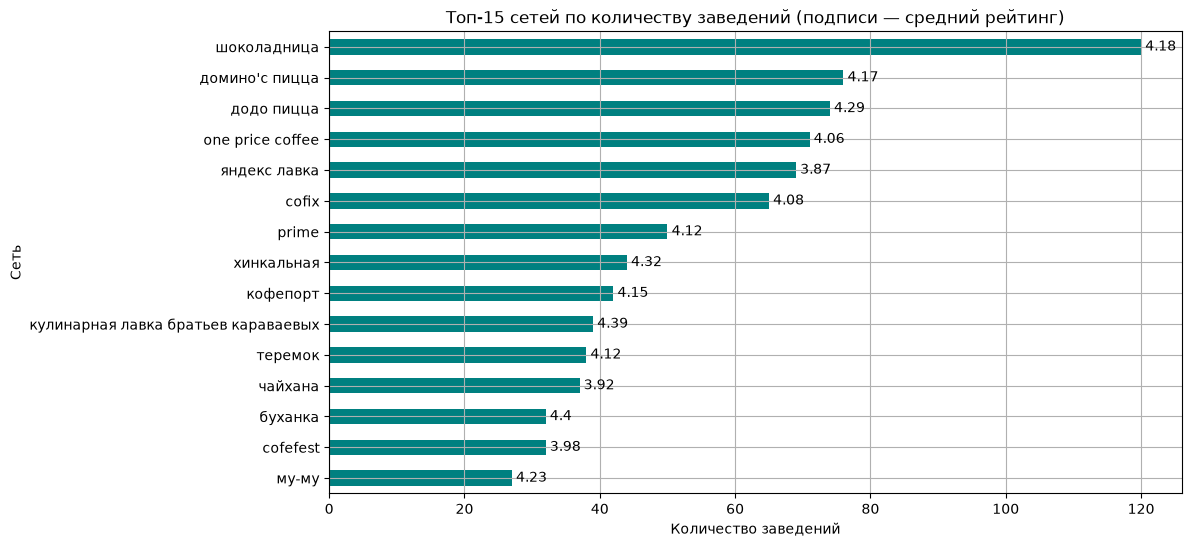

In [51]:
# Делаем срез топ-15 сетей по количеству заведений
top15 = grouped.head(15)

# Переворачиваем порядок: в barh столбики рисуются снизу вверх,
# поэтому для сортировки по убыванию сверху нужен порядок по возрастанию
top15_sorted = top15.sort_values('places_count')

# Строим горизонтальную столбчатую диаграмму по количеству заведений
ax = top15_sorted['places_count'].plot(
    kind='barh',
    legend=False,
    color='teal',
    figsize=(11, 6),
    title='Топ-15 сетей по количеству заведений (подписи — средний рейтинг)'
)

# В подписях выводим не количество, а средний рейтинг сети
ax.bar_label(ax.containers[0], labels=top15_sorted['rating'].round(2), padding=3)

# Настраиваем оформление графика
plt.ylabel('Сеть')
plt.xlabel('Количество заведений')
plt.grid()
plt.show()

In [52]:
# Столбец name_lower был нужен только для группировки сетей по названию
# и в дальнейшем анализе не понадобится, поэтому удаляем его
df = df.drop(columns='name_lower')

**Вывод:**

1. Самая крупная сеть — «Шоколадница» (120 заведений), это кофейня, и она в 1,6 раза больше следующей. На втором и третьем месте две пиццерии: «Домино'с пицца» (76) и «Додо пицца» (74). Замыкает топ кафе «Му-Му» (27) — в 4,4 раза меньше, чем у лидера.
2. Чаще всего в топ-15 встречаются кофейни (5 сетей), далее кафе (4) и рестораны (3). Это согласуется с выводом из 3.3: у кофеен одна из самых высоких долей сетевых заведений — 51%.
3. По рейтингам картина неожиданная: масштаб сети не означает высокую оценку. Только четыре из пятнадцати крупнейших сетей держатся выше общего среднего по городу (4.23) — «буханка» (4.4), «кулинарная лавка братьев Караваевых» (4.39), «хинкальная» (4.32) и «додо пицца» (4.29). Остальные десять ниже, причем «яндекс лавка» (3.87), «чайхана» (3.92) и cofefest (3.98) не дотягивают даже до 4. Два самых крупных игрока — «Шоколадница» (4.18) и «Домино'с пицца» (4.17) — тоже ниже городского уровня.
4. Почему так, данные не говорят. Можно предположить, что массовый формат сложнее удерживать на одном уровне качества, но проверить это нельзя — числа отзывов у нас нет.
5. При интерпретации топа нужно учитывать два ограничения. Во-первых, группировка по названию не отличает точки одной сети от независимых заведений с тем же названием: «хинкальная» и «чайхана» — родовые слова. Во-вторых, «яндекс лавка» — сервис доставки продуктов, а не заведение общепита; в топ она попала из-за категоризации в исходных данных (и по той же причине помечена как «ресторан»).

<a id="step3-8"></a>
### 3.8. Средний чек в зависимости от района

Изучим, как меняется средний чек заведения (столбец `middle_avg_bill`) в зависимости от административного округа Москвы. Отдельно сравним цены в Центральном округе с остальными и посмотрим, как удаленность от центра связана с чеком. Результат сопроводим визуализациями.

Важно учитывать, что `middle_avg_bill` заполнен только у 3149 заведений из 8403 (37%), поэтому все выводы этого раздела относятся к подвыборке, а не ко всему рынку. Прежде чем считать средние, проверим, сколько заведений с указанным чеком приходится на каждый округ.

In [53]:
# Смотрим, сколько заведений с указанным средним чеком есть в каждом округе
df.groupby('district')['middle_avg_bill'].count()

district
Восточный административный округ            260
Западный административный округ             306
Северный административный округ             322
Северо-Восточный административный округ     301
Северо-Западный административный округ      157
Центральный административный округ         1060
Юго-Восточный административный округ        194
Юго-Западный административный округ         235
Южный административный округ                314
Name: middle_avg_bill, dtype: int64

Заведения с указанным чеком распределены по округам неравномерно: больше всего их в Центральном округе (1060), меньше всего в Северо-Западном (157). Группы достаточно наполнены, чтобы считать по ним медиану, но к округам с небольшим числом наблюдений стоит относиться осторожнее.


In [54]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

По распределению видно, что средний чек сильно скошен вправо. Медиана — 750 рублей, а среднее заметно выше (958), при максимуме 35 000. Стандартное отклонение (1010) даже больше самого среднего — это признак длинного правого хвоста.

Чек 35 000 рублей выглядит реальным для дорогого ресторана, поэтому считать его ошибкой нельзя. Но таких заведений единицы, а типичное значение при этом в разы ниже. В отличие от рейтинга, у чека нет верхней границы: несколько очень дорогих заведений способны заметно поднять среднее по округу, и оно перестанет описывать типичное заведение. Поэтому дальше используем медиану, а не среднее — она устойчива к таким выбросам.

Посчитаем медианный чек по административным округам.

In [55]:
# Считаем медианный чек по округам
df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False)

district
Западный административный округ            1000.0
Центральный административный округ         1000.0
Северо-Западный административный округ      700.0
Северный административный округ             650.0
Юго-Западный административный округ         600.0
Восточный административный округ            575.0
Северо-Восточный административный округ     500.0
Южный административный округ                500.0
Юго-Восточный административный округ        450.0
Name: middle_avg_bill, dtype: float64

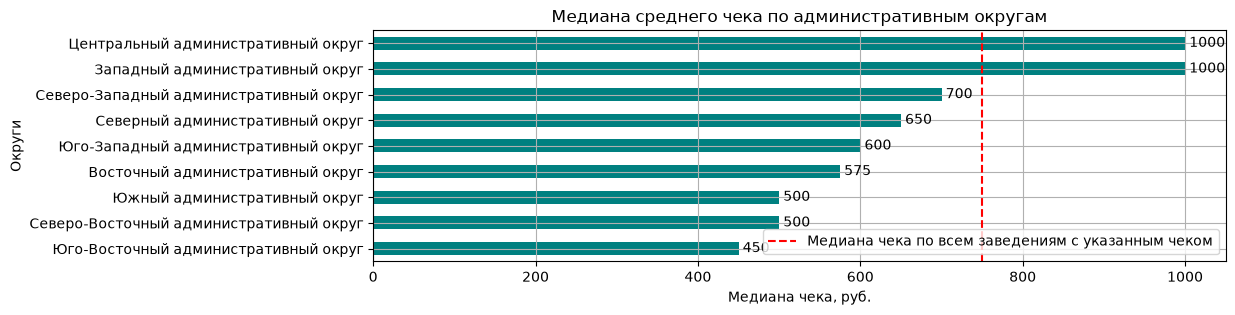

In [56]:
# Создаем контейнер графика matplotlib и задаем его размер
plt.figure(figsize=(11, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='barh'), высчитывая медиану чека для округов
ax = df.groupby('district')['middle_avg_bill'].median().sort_values().plot(
               kind='barh', # Тип графика - горизонтальная диаграмма
               legend=False, # Выключаем легенду
               color='teal',
               title='Медиана среднего чека по административным округам'
)

ax.bar_label(ax.containers[0], padding=3)  # подписи значений на концах столбиков

# Построим линию медианы значения, чтобы явно понять какие категории обычно хуже
line = plt.axvline(df['middle_avg_bill'].median(), color='red', linestyle='--',
                   label='Медиана чека по всем заведениям с указанным чеком')
plt.legend(handles=[line], loc='lower right')

# Настраиваем оформление графика
plt.ylabel('Округи')
plt.xlabel('Медиана чека, руб.')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [57]:
# Сравнение ЦАО с остальными округами
print('Медиана чека в ЦАО:',
      df[df['district'] == 'Центральный административный округ']['middle_avg_bill'].median())
print('Медиана чека в остальных округах:',
      df[df['district'] != 'Центральный административный округ']['middle_avg_bill'].median())

Медиана чека в ЦАО: 1000.0
Медиана чека в остальных округах: 600.0


**Вывод:**

1. Медианный чек различается между округами более чем в два раза: от 1000 руб. в Центральном и Западном округах до 450 руб. в Юго-Восточном.
2. Ожидалось, что лидером будет ЦАО, но данные показали иное — первое место он делит с Западным округом, там такой же чек в 1000 руб.
3. Простая формула «чем дальше от центра, тем дешевле» не работает. Западный и Северо-Западный округа дорогие, а Юго-Восточный и Южный дешевые, хотя по удаленности от центра они сопоставимы. Можно предположить, что дело скорее в престижности района и доходах жителей, чем в расстоянии, но проверить это на имеющихся данных нельзя.
4. Нужно учитывать ограничение: средний чек указан только у 37% заведений, причем треть этой подвыборки — сам ЦАО (1060 из 3149). Поэтому общая медиана по городу (750 руб.) во многом определяется центром.

Что это значит для заказчика: чтобы получить высокий чек, необязательно открываться в центре. Западный округ дает такую же медиану (1000 руб.), но заведений там 850 против 2242 в ЦАО — то есть при сопоставимом чеке конкуренция заметно ниже. При этом высокий чек сам по себе не гарантирует выручку: она зависит и от посещаемости, а данных о потоке гостей у нас нет — это потребует отдельного исследования.

<a id="step3-sum"></a>
### Обобщение результатов исследования

**Где открывать.** Центральный округ перенасыщен: 2242 заведения — в 2,5 раза больше, чем в следующем по количеству Северном (899). Остальные округа сопоставимы между собой (примерно 700–900), заметно отстает только Северо-Западный (409). При этом высокий чек не является привилегией центра: медиана 1000 руб. одинакова в Центральном и Западном округах, но заведений в Западном 850 против 2242 — при том же чеке конкуренция там заметно ниже. Разброс медианного чека по городу превышает двукратный: от 1000 руб. до 450 руб. в Юго-Восточном округе. Простая закономерность «чем дальше от центра, тем дешевле» не подтверждается — дорогие и дешевые округа встречаются на сопоставимом удалении.

**Что открывать.** Рынок держится на трех форматах: кафе (2377), рестораны (2042) и кофейни (1413). Узкие форматы представлены слабо — столовых 315, булочных 256, разрыв с лидером почти десятикратный. В центре структура другая: там рестораны (670) обгоняют кафе (464), а бары и пабы (364) подтягиваются к лидерам — центр смещен в сторону дорогих и вечерних форматов.

**Конкуренция с сетями.** Большинство заведений города несетевые — 62% против 38%. Но по категориям картина разная: чаще всего сетевыми оказываются стандартизируемые форматы (булочные 61%, пиццерии 52%, кофейни 51%), реже — те, где важна уникальность концепции или привязка к месту (бары 22%, столовые 28%). Крупнейшие сети — «Шоколадница» (120 заведений), «Домино'с пицца» (76), «Додо пицца» (74); больше всего среди них кофеен.

**На что не стоит рассчитывать.** Рейтинг почти не связан ни с расположением, ни с форматом, ни с ценовой категорией, ни с сетевым статусом — все коэффициенты phi_k слабые (максимум 0.22 у цены), а с количеством мест связи нет вовсе. Средние рейтинги по категориям различаются всего на 0.34 балла, что меньше стандартного отклонения внутри выборки. Это значит, что хорошую оценку нельзя получить удачным выбором локации или формата: она зависит от того, чего в данных нет — качества еды, сервиса, атмосферы. Косвенно это подтверждает и топ-15 сетей: только четыре из пятнадцати крупнейших держатся выше среднего рейтинга по городу.

**Ориентир по размеру.** Типичное заведение имеет около 75 посадочных мест, основная масса — от 40 до 140. По категориям типичные размеры близки (медианы 50–86 мест), поэтому формат почти не определяет масштаб зала.

**Ограничения исследования.** Данные охватывают лето 2022 года и содержат существенные пропуски: количество мест указано у 57% заведений, средний чек — у 37%, ценовая категория — у 39%. Выводы о ценах опираются на подвыборку, треть которой приходится на Центральный округ. Кроме того, в данных нет числа оценок, поэтому рейтинг 5.0 по нескольким отзывам формально выглядит так же весомо, как 4.4 по тысяче.

<a id="step4"></a>
## 4. Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В ходе исследования проанализировали данные о 8406 заведениях общественного питания Москвы, собранные на основе сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Информация была разделена на два файла: характеристики заведений (название, адрес, административный округ, категория, часы работы, рейтинг, признак сетевого заведения, количество посадочных мест) и данные о ценах (ценовая категория, средний чек, цена чашки капучино). Датасеты объединили по столбцу `id` левым присоединением, чтобы сохранить все заведения независимо от наличия у них информации о ценах.

На этапе предобработки изучили пропуски и приняли решение оставить их: профилирование не выявило системной причины, а в ценовых столбцах пропуски структурны. Проверили корректность типов данных, нашли и удалили 3 неявных дубликата по паре «название — адрес» (0,04% данных), после чего в работе осталось 8403 заведения. Дополнительно выделили признак круглосуточной работы `is_24_7`.

Исследовательский анализ провели по восьми направлениям: распределение заведений по категориям и административным округам, соотношение сетевых и несетевых заведений, количество посадочных мест, рейтинги, связь рейтинга с остальными характеристиками, топ-15 популярных сетей и средний чек в зависимости от района.

### Главные выводы

**Профиль типичного заведения Москвы.** Чаще всего это кафе (2377 заведений, 28% рынка), ресторан (2042, 24%) или кофейня (1413, 17%). С высокой вероятностью оно несетевое — таких 62%. Имеет около 75 посадочных мест (основная масса заведений — от 40 до 140), рейтинг около 4.23 и средний чек порядка 750 рублей. Круглосуточно работают 9% заведений. Каждое четвертое заведение города расположено в Центральном административном округе.

**1. Рынок концентрирован по форматам.** Три категории — кафе, рестораны и кофейни — составляют почти 70% всех заведений. Узкие форматы представлены слабо: столовых 315, булочных 256, разрыв с лидером почти десятикратный.

**2. Центр перенасыщен, и структура рынка в нем иная.** В ЦАО 2242 заведения — в 2,5 раза больше, чем в следующем по количеству Северном округе (899). Остальные округа сопоставимы между собой (примерно 700–900), заметно отстает Северо-Западный (409). При этом в центре на первое место выходят рестораны (670) и подтягиваются бары (364), тогда как по городу лидируют кафе, — центр смещен в сторону дорогих и вечерних форматов.

**3. Сетевые заведения занимают стандартизируемые ниши.** В целом по городу несетевых больше — 62% против 38%. Но доля сетевых сильно зависит от категории: булочные 61%, пиццерии 52%, кофейни 51% против баров 22% и столовых 28%. Сети чаще там, где меню и процесс легко копировать под единым брендом, и реже там, где важна уникальность концепции или привязка к месту. Крупнейшие сети — «Шоколадница» (120 заведений), «Домино'с пицца» (76), «Додо пицца» (74).

**4. Рейтинг практически не связан с изученными характеристиками.** Матрица корреляции phi_k показала только слабые связи: ценовая категория 0.22, округ 0.20, категория 0.19, круглосуточность 0.15, сетевой статус 0.11, количество мест — 0.00. Средние рейтинги по категориям различаются всего на 0.34 балла, что меньше стандартного отклонения внутри выборки (0.47). Проверка самой сильной связи подтвердила слабую тенденцию: чек растет — рейтинг растет (4.17 → 4.44), но разница мизерная. Отсутствие сильных зависимостей — это тоже результат: он означает, что оценка заведения определяется тем, чего в данных нет, — качеством еды, сервисом и атмосферой. Косвенно это подтверждает топ-15 сетей: только четыре из пятнадцати крупнейших держатся выше среднего рейтинга по городу.

**5. Высокий чек не привязан к центру.** Медианный чек различается между округами более чем в два раза: от 1000 рублей в Центральном и Западном округах до 450 рублей в Юго-Восточном. Простая закономерность «чем дальше от центра, тем дешевле» не подтверждается — дорогие и дешевые округа встречаются на сопоставимом удалении от центра.

### Рекомендации

**1. Рассмотреть Западный округ как альтернативу центру.** Медианный чек там такой же, как в ЦАО (1000 рублей), но заведений 850 против 2242 — при сопоставимом чеке конкуренция почти втрое ниже. Открываться в Центральном округе имеет смысл только с сильным и отличающимся продуктом: рынок там насыщен, и клиенту есть из чего выбирать. При этом высокий средний чек сам по себе не гарантирует высокую выручку: она зависит еще и от числа гостей, а данных о посещаемости у нас нет. Может оказаться, что в округе с чеком 1000 рублей клиентов заметно меньше, чем в округе с чеком 500.
   
**2. Осторожно относиться к округам с малым числом заведений.** Северо-Западный округ выглядит свободным (409 заведений), но низкая конкуренция может означать как незанятую нишу, так и слабый спрос. Без данных о трафике и платежеспособности жителей заходить туда рискованно.

**3. Выбирать формат с учетом сетевой конкуренции.** Если проект несетевой, то булочные, пиццерии и кофейни — сложное поле: там 51–61% заведений принадлежат сетям, и придется конкурировать с узнаваемыми брендами. Форматы, где сетей мало (бары и пабы — 22%, столовые — 28%), оставляют больше пространства одиночному заведению с собственной концепцией.

**4. Ориентироваться на зал примерно на 75 посадочных мест.** Это типичный размер для заведений любой категории — медианы по категориям близки (50–86 мест). Крупные залы на 500 и более мест встречаются, но это единичные случаи, а не рыночная норма. Гнаться за размером зала ради оценки посетителей смысла нет: количество мест — единственная характеристика, у которой коэффициент phi_k с рейтингом оказался равен нулю, то есть большие заведения оценивают не лучше и не хуже маленьких.

**5. Не рассчитывать получить высокий рейтинг за счет локации, формата или цены.** Данные показывают, что эти факторы с оценкой почти не связаны. Бюджет разумнее вкладывать в качество кухни, сервис и атмосферу — то, что формирует рейтинг, но в данных не отражено.

**6. Провести дополнительные исследования перед окончательным решением.** Текущий анализ отвечает на вопрос «где и какие заведения есть», но не отвечает на вопрос «где на них есть спрос». Для выбора места стоит дополнительно изучить:
- посещаемость и пешеходный трафик по районам — высокий чек не гарантирует выручку;
- количество отзывов у заведений: в данных есть только рейтинг, поэтому оценка 5.0 по нескольким отзывам формально выглядит так же весомо, как 4.4 по тысяче;
- динамику рынка за несколько лет — текущие данные охватывают только лето 2022 года и не показывают, какие форматы растут, а какие сжимаются;
- арендные ставки по округам, чтобы сопоставить их с ожидаемым чеком.

### Ограничения исследования

Выводы стоит рассматривать с учетом качества исходных данных. Информация носит справочный характер и частично добавлена пользователями сервисов. Количество посадочных мест указано у 57% заведений, ценовая категория — у 39%, средний чек — у 37%, поэтому выводы о ценах опираются на подвыборку, треть которой приходится на Центральный округ. Признак сетевого заведения, по описанию данных, может содержать ошибки для небольших сетей. Кроме того, группировка по названию не отличает точки одной сети от независимых заведений с тем же названием, а данные охватывают только один сезон — лето 2022 года.
